# Libraries



In [1]:
import sys
from pathlib import Path

# Add repo root so benchmarking.helpers is importable
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

# path to benchmarking/benchmarks
benchmarks_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    discover_benchmark_names,
    plot_overall_hitrate,
    plot_overall_ndcg,
    plot_overall_diversity,
    plot_overall_mrr,
    plot_group_bar_plot,
)

system_version = "v16"
benchmark_names = discover_benchmark_names(benchmarks_path)

print("System version:", system_version)
print("Benchmarks discovered:", benchmark_names)


System version: v16
Benchmarks discovered: ['Cloudbench', 'Commonobjectsbench', 'Firebench', 'INQUIRE', 'Sagebench']


# Evaluating ALL Benchmarks

Here we will evaluate the raw query metrics returned by all benchmarks based on `v16` system version.


## Overall Hit Rate Across Benchmarks

Hit rate (Success@25) = fraction of queries with at least one relevant image in the top 25.

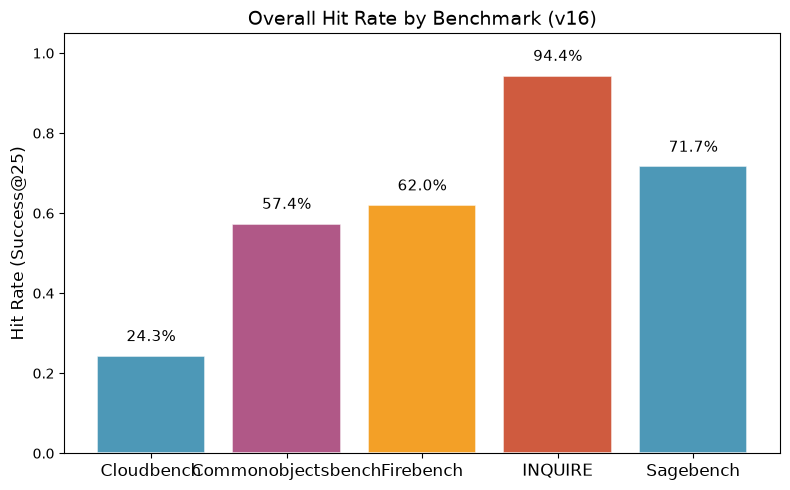

In [2]:
plot_overall_hitrate(
    system_version=system_version,
    base_path=benchmarks_path,
    response_limit=25
)

## Overall Diversity Across Benchmarks

Diversity measures the diversity of the retrieved images; higher means more diverse images are retrieved.

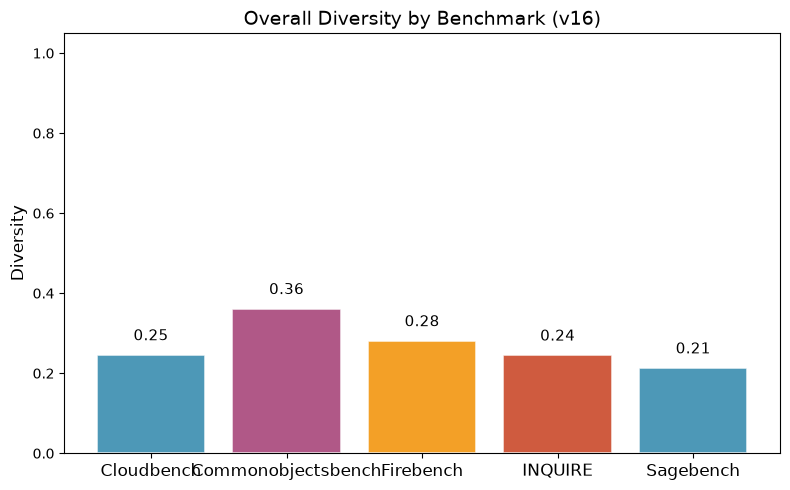

In [3]:
plot_overall_diversity(
    system_version=system_version,
    base_path=benchmarks_path,
)

## Overall MRR Across Benchmarks

MRR (Mean Reciprocal Rank) measures how early the first relevant result appears.


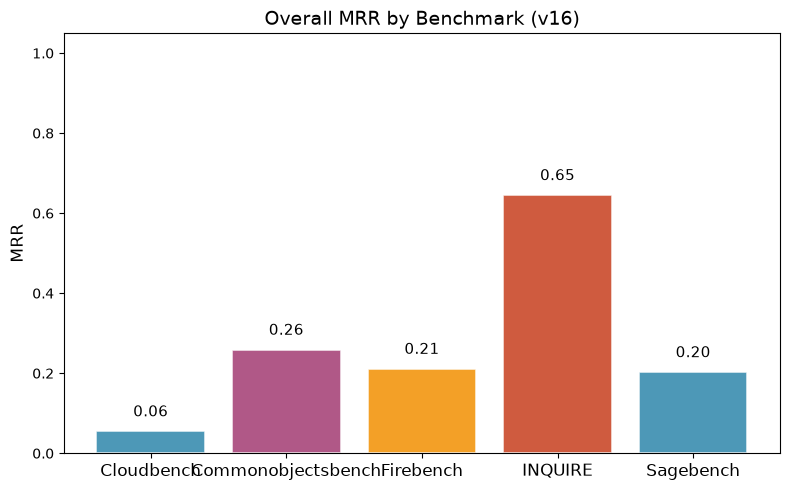

In [4]:
plot_overall_mrr(
    system_version=system_version,
    base_path=benchmarks_path,
)

## Overall NDCG Across Benchmarks

NDCG (Normalized Discounted Cumulative Gain) measures ranking quality; higher means relevant images are ranked higher.

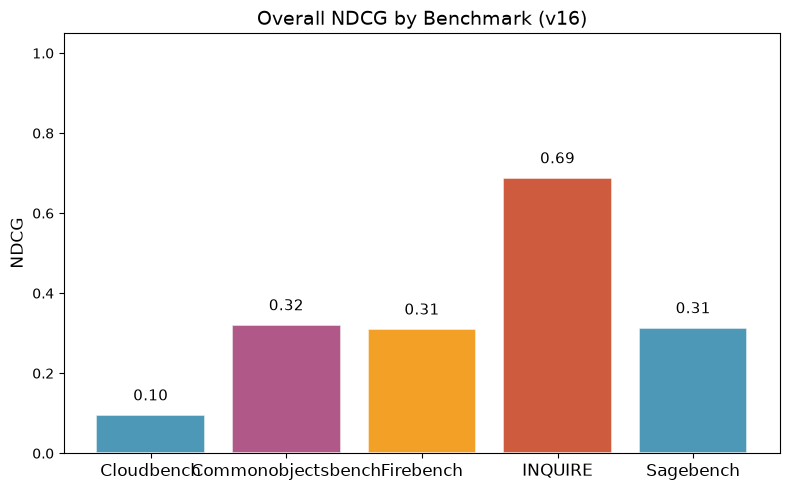

In [5]:
plot_overall_ndcg(
    system_version=system_version,
    base_path=benchmarks_path,
)

## Insights & Conclusion

v16 is **query-only** (`SKIP_INDEX=true`) on the v15 collections. No recaption. Plots in this notebook are production pick **H** (`query_alpha=0.65`, `clip_alpha=0.7` → **46% image / 20% caption / 35% BM25**). The A–H sweep is archived under each bench's `results/v16/v16_qa*` folders.

**Equal-bench composite** (mean over five benches of `0.5 × hit + 0.5 × hybrid MRR`):

| System | Composite | Notes |
| ------ | --------- | ----- |
| v12 | 0.402 | Weaviate fused index |
| v13 | 0.437 | Milvus dual-index / CLIP DFN |
| v15 | 0.410 | two-caption ingest, `query_alpha=0.4` |
| **H (v16)** | **0.447** | **`query_alpha=0.65` / `clip_alpha=0.7`** |
| E | 0.452 | `query_alpha=0.70` — **rejected** |
| B | 0.447 | `query_alpha=0.60` — round-number fallback |

**Guardrails**

- Query-matched Fire MRR is **H 0.21** (E 0.20). The old 0.65 Fire MRR guardrail used labels from other queries and is not used here. Sage hit remains the binding constraint.
- Sage hit ≥ 64%: **H 71.7%**. **E 63.3% fails.** This is the reason we stop at 0.65.

**Why each `v16_qa*` batch was run.** Folder names encode the knobs (`qa` = `query_alpha`, `ca` = `clip_alpha`). Hybrid weights are `WeightedRanker(query_alpha × clip_alpha, query_alpha × (1 − clip_alpha), 1 − query_alpha)` → image / caption / BM25. All seven jobs are **skip-index** on the v15 collections (no recaption). They were launched in three waves so later jobs could condition on earlier ones. Archives live under each bench's `results/v16/v16_qa*`.

| Wave | Letter | Folder | query_alpha | clip_alpha | weights | Question | Cross-bench result |
| ---- | ------ | ------ | ----------- | ---------- | ------- | -------- | ------------------ |
| 1 | A | `v16_qa04_ca085` | 0.40 | 0.85 | 34 / 6 / 60 | Does the image/caption split matter while BM25 is 60%? | 100% hit overlap with v15 on every bench. |
| 1 | C | `v16_qa04_ca05` | 0.40 | 0.50 | 20 / 20 / 60 | Same question, more caption instead of more image. | 100% hit overlap with v15 on every bench. |
| 1 | B | `v16_qa06_ca07` | 0.60 | 0.70 | 42 / 18 / 40 | Is dense vs BM25 the lever? | First real move. Composite 0.447. Unlock on Commonobjects / Fire / INQUIRE / Sage; Cloudbench soft-miss. |
| 2 | D | `v16_qa05_ca07` | 0.50 | 0.70 | 35 / 15 / 50 | Where does the BM25 lock break — 0.50 or 0.60? | Still locked (same hits as v15). Unlock is at 0.60, not 0.50. |
| 2 | E | `v16_qa07_ca07` | 0.70 | 0.70 | 49 / 21 / 30 | Can we push past B, or do Sage/Cloud fall off? | Composite 0.452 but **rejected**: Sage 63.3% fails the 64% floor (night 61% → 44%); Cloudbench 20%. |
| 2 | F | `v16_qa06_ca085` | 0.60 | 0.85 | 51 / 9 / 40 | Is `clip_alpha` alive once BM25 is 40%? | Identical to B except tiny MRR jitter (Commonobjects −1 hit). |
| 3 | **H** | **`v16_qa065_ca07`** | **0.65** | **0.70** | **46 / 20 / 35** | Sit between B (unlock, Sage holds) and E (Sage fails). | **Winner.** Composite 0.447. Only point that beats B (INQUIRE +2 queries). Sage 71.7% holds. Copied to `results/v16/`. |

**Phase transition**

- **BM25-locked** through `query_alpha=0.5` (A/C/D = v15 hit sets). Wave 1's `clip_alpha` pair (A, C) is a no-op; D confirms the lock survives a 10-point BM25 cut.
- **Unlocks at 0.6** (B): Commonobjects, Fire, INQUIRE, Sage all move; Cloudbench soft-misses. F then shows `clip_alpha` is still dead after the unlock.
- **H (0.65)** is the only point that beats B (INQUIRE +2 queries). Sage still holds. That is why Wave 3 exists.
- **Sage cliff at 0.70** (E): Sage 71.7% → 63.3%, night 61% → 44%. Cloudbench crashes to 20%. Composite 0.452 is not usable.

**`clip_alpha` is a no-op in this band.** A and C match v15 hits. F matches B except tiny MRR jitter. Do not queue more `clip_alpha` jobs while BM25 ≥ 40%.

**Production pick: H.** Round-number fallback **B** (`query_alpha=0.60`) if 0.65 is too specific. **Do not take E.**
